In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 27.4 MB/s eta 0:00:00


In [ ]:
# 세그멘테이션 모델 로드 (n, s, m, l, x 크기 선택 가능)
# model = YOLO('yolov8s-seg.pt')  # small
# model = YOLO('yolov8m-seg.pt')  # medium
# model = YOLO('yolov8l-seg.pt')  # large
# model = YOLO('yolov8x-seg.pt')  # extra large


image 1/1 /content/test_seg.jpg: 384x640 2 persons, 1 dog, 460.5ms
Speed: 12.6ms preprocess, 460.5ms inference, 47.8ms postprocess per image at shape (1, 3, 384, 640)


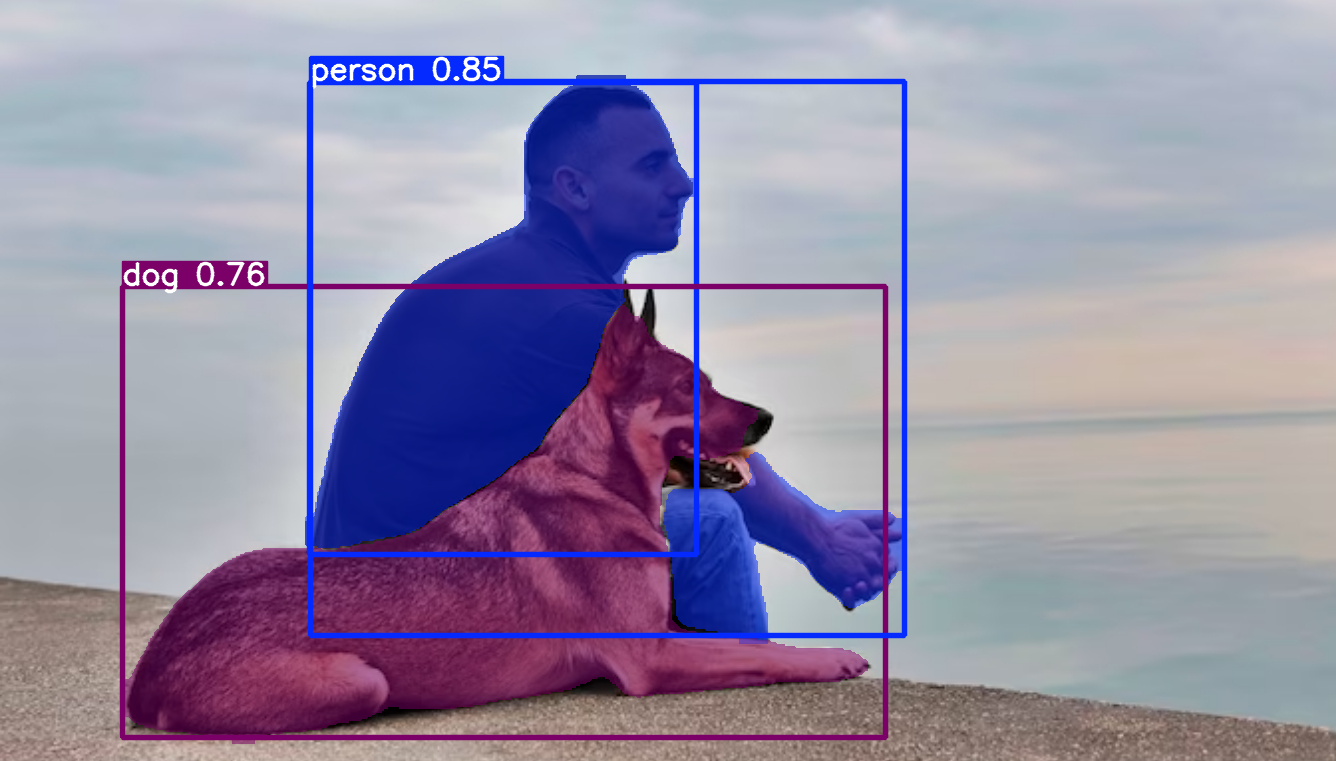

'result.jpg'

In [3]:
from ultralytics import YOLO
model = YOLO('yolov8n-seg.pt')
results = model('/content/test_seg.jpg')
results[0].show()
results[0].save('result.jpg')

In [24]:
# Instance
print(len(result.masks.data))  # 3 (각각 별도 마스크)
print(len(result.boxes))       # 3 (각각 별도 바운딩박스)

3
3


In [10]:
# 결과접근
for result in results:
    # 바운딩 박스
    boxes = result.boxes.xyxy  # [x1, y1, x2, y2] 형식
    print(boxes)
    print('-'*100)
    # 마스크
    masks = result.masks.data  # 세그멘테이션 마스크
    print(masks.min(), masks.max())
    # 클래스 및 신뢰도
    classes = result.boxes.cls
    confidences = result.boxes.conf

tensor([[310.8728,  81.1315, 904.2048, 635.1538],
        [122.8671, 286.8805, 885.1402, 737.8978],
        [309.7816,  82.9716, 696.9297, 554.9960]])
----------------------------------------------------------------------------------------------------
tensor(0, dtype=torch.uint8) tensor(1, dtype=torch.uint8)


In [13]:
# 마스크와 클래스 매칭

from ultralytics import YOLO

model = YOLO('yolov8n-seg.pt')
results = model('/content/test_seg.jpg')

for result in results:
    # 클래스 이름 가져오기
    names = result.names  # {0: 'person', 1: 'bicycle', ...}

    # 각 검출된 객체별로 순회
    for i, (mask, box) in enumerate(zip(result.masks.data, result.boxes)):
        cls_id = int(box.cls)           # 클래스 ID (숫자)
        cls_name = names[cls_id]        # 클래스 이름
        conf = float(box.conf)          # 신뢰도

        print(f"객체 {i}: {cls_name} (ID: {cls_id}), 신뢰도: {conf:.2f}")
        print(f"마스크 shape: {mask.shape}")


## 출력 예시
#```
#객체 0: person (ID: 0), 신뢰도: 0.92
#마스크 shape: torch.Size([640, 640])
#객체 1: car (ID: 2), 신뢰도: 0.87
#마스크 shape: torch.Size([640, 640])


image 1/1 /content/test_seg.jpg: 384x640 2 persons, 1 dog, 315.3ms
Speed: 6.4ms preprocess, 315.3ms inference, 16.2ms postprocess per image at shape (1, 3, 384, 640)
객체 0: person (ID: 0), 신뢰도: 0.85
마스크 shape: torch.Size([384, 640])
객체 1: dog (ID: 16), 신뢰도: 0.76
마스크 shape: torch.Size([384, 640])
객체 2: person (ID: 0), 신뢰도: 0.46
마스크 shape: torch.Size([384, 640])


In [15]:
# 특정클래스만 필터링
for i, (mask, box) in enumerate(zip(result.masks.data, result.boxes)):
    cls_id = int(box.cls)
    cls_name = names[cls_id]

    if cls_name == 'person':  # person만 처리
        # mask는 해당 객체의 이진 마스크 (0: 배경, 1: 객체)
        person_mask = mask.cpu().numpy()


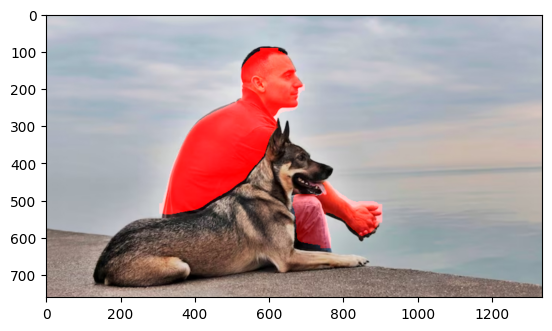

True

In [21]:
# 마스크 시각화, 사람영역
import cv2
import numpy as np

img = cv2.imread('/content/test_seg.jpg')

for i, (mask, box) in enumerate(zip(result.masks.data, result.boxes)):
    if names[int(box.cls)] == 'person':
        person_mask = mask.cpu().numpy()

        # 마스크를 원본 이미지 크기로 리사이즈
        person_mask = cv2.resize(person_mask, (img.shape[1], img.shape[0]))

        # 마스크 시각화 (빨간색 오버레이)
        colored_mask = np.zeros_like(img)
        colored_mask[person_mask > 0.5] = [0, 0, 255]  # BGR
        img = cv2.addWeighted(img, 1, colored_mask, 0.5, 0)

import matplotlib.pyplot as plt
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

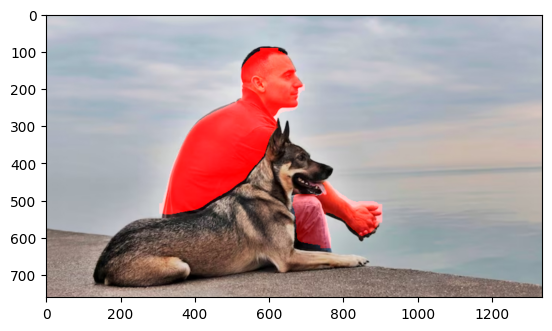

In [23]:
# 사람만 잘라내기

for i, (mask, box) in enumerate(zip(result.masks.data, result.boxes)):
    if names[int(box.cls)] == 'person':
        person_mask = mask.cpu().numpy()
        person_mask = cv2.resize(person_mask, (img.shape[1], img.shape[0]))

        # 배경 제거 (투명 PNG)
        mask_bool = person_mask > 0.5
        result_img = np.zeros((img.shape[0], img.shape[1], 4), dtype=np.uint8)
        result_img[:, :, :3] = img
        result_img[:, :, 3] = (mask_bool * 255).astype(np.uint8)

        cv2.imwrite(f'person_{i}.png', result_img)
